In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
os.makedirs('charts', exist_ok=True)

In [27]:
df = pd.read_excel('/Users/swaransh/Downloads/Data Visualisation - COM7021 - [4566] Bakery- supporting document (1).xlsx')
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Date             0
City             0
Confectionary    0
Units Sold       5
Revenue(£)       9
Cost(£)          9
Profit(£)        3
dtype: int64


In [28]:
df['Units Sold'] = df['Units Sold'].fillna(df['Units Sold'].median())
df['Revenue(£)'] = df['Revenue(£)'].fillna(df['Revenue(£)'].median())
df['Cost(£)']    = df['Cost(£)'].fillna(df['Cost(£)'].median())
df['Profit(£)']  = df['Profit(£)'].fillna(df['Profit(£)'].median())

In [29]:
print(df.isnull().sum())

Date             0
City             0
Confectionary    0
Units Sold       0
Revenue(£)       0
Cost(£)          0
Profit(£)        0
dtype: int64


In [30]:
df['Confectionary'] = df['Confectionary'].str.strip()
df['Confectionary'] = df['Confectionary'].replace({
    'Choclate Chunk': 'Chocolate Chunk',
    'Caramel nut':    'Caramel Nut'
})

df['Year'] = df['Date'].dt.year

In [31]:
print(df.shape)

(1001, 8)


In [32]:
city_profit = df.groupby('City')['Profit(£)'].sum().sort_values(ascending=False).reset_index()
conf_profit = df.groupby('Confectionary')['Profit(£)'].sum().sort_values().reset_index()
annual      = df.groupby(['Year', 'City'])['Profit(£)'].sum().reset_index()
pivot       = df.groupby(['City', 'Confectionary'])['Profit(£)'].sum().unstack(fill_value=0)
city_rev    = df.groupby('City')['Revenue(£)'].sum()

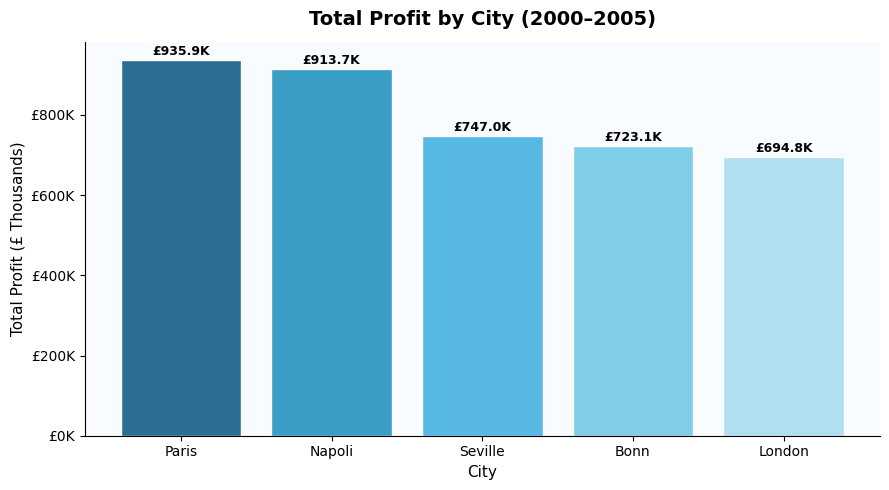

In [33]:
# Group the data by city and add up all the profit
city_profit = df.groupby('City')['Profit(£)'].sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))  # create a blank chart canvas 9 inches wide, 5 tall

colors = ['#2C6E91','#3A9DC4','#56B8E3','#80CDE8','#B0DFF0']  # five shades of blue

# Draw the bars. We divide by 1000 so the numbers show as "£929K" not "£929000"
bars = ax.bar(city_profit['City'], city_profit['Profit(£)'] / 1000, color=colors, edgecolor='white')


ax.set_title('Total Profit by City (2000–2005)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('City', fontsize=11)
ax.set_ylabel('Total Profit (£ Thousands)', fontsize=11)

# Format the Y axis to show £ symbol and K suffix
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))


for bar, val in zip(bars, city_profit['Profit(£)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'£{val/1000:,.1f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('#F8FBFF')
plt.tight_layout()
plt.savefig('charts/chart1_profit_by_city.png', dpi=150, bbox_inches='tight')
plt.show()

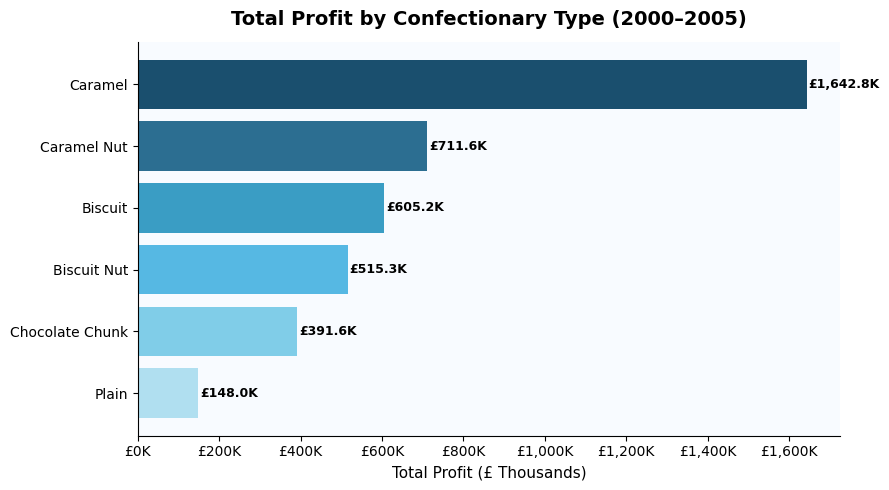

In [34]:
# Group by confectionary type and sum profit, sorted lowest to highest
conf_profit = df.groupby('Confectionary')['Profit(£)'].sum().sort_values().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
colors2 = ['#B0DFF0','#80CDE8','#56B8E3','#3A9DC4','#2C6E91','#1A4F6E']


ax.barh(conf_profit['Confectionary'], conf_profit['Profit(£)'] / 1000, color=colors2)

ax.set_title('Total Profit by Confectionary Type (2000–2005)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Profit (£ Thousands)', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))


for bar, val in zip(ax.patches, conf_profit['Profit(£)']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'£{val/1000:,.1f}K', va='center', fontsize=9, fontweight='bold')

ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('#F8FBFF')
plt.tight_layout()
plt.savefig('charts/chart2_profit_by_confectionary.png', dpi=150, bbox_inches='tight')
plt.show()

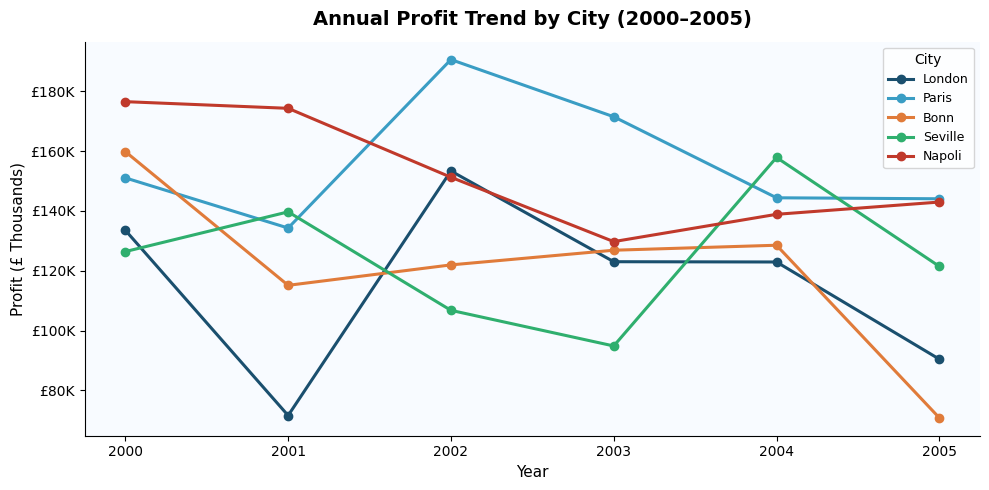

In [35]:
# Group by both Year AND City to get yearly profit per city
annual_city = df.groupby(['Year','City'])['Profit(£)'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
palette = ['#1A4F6E','#3A9DC4','#E07B3A','#2FAF6E','#C0392B']  # one colour per city

# Loop through each city and draw one line per city
for i, city in enumerate(df['City'].unique()):
    data = annual_city[annual_city['City'] == city]
    ax.plot(data['Year'], data['Profit(£)']/1000, marker='o', label=city,
            color=palette[i], linewidth=2.2, markersize=6)


ax.set_title('Annual Profit Trend by City (2000–2005)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Profit (£ Thousands)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
ax.legend(title='City', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('#F8FBFF')
plt.tight_layout()
plt.savefig('charts/chart3_annual_trend.png', dpi=150, bbox_inches='tight')
plt.show()

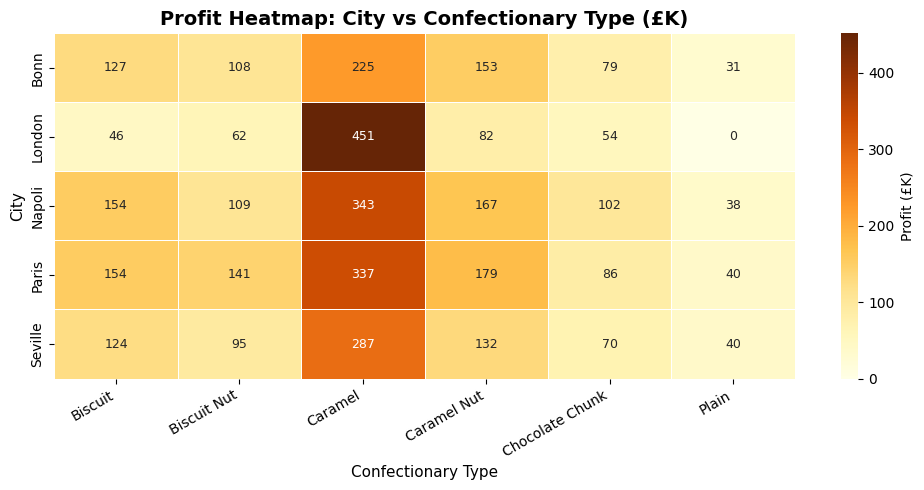

In [36]:
# Create a pivot table: rows = cities, columns = confectionary types, values = profit
pivot = df.groupby(['City','Confectionary'])['Profit(£)'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
# sns.heatmap draws colour-coded boxes for each city+product combination
sns.heatmap(pivot/1000, annot=True, fmt='.0f', cmap='YlOrBr', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Profit (£K)'}, annot_kws={'size': 9})
            # cmap='YlOrBr' = yellow→orange→brown colour scale

ax.set_title('Profit Heatmap: City vs Confectionary Type (£K)', fontsize=14, fontweight='bold')
ax.set_xlabel('Confectionary Type', fontsize=11)
ax.set_ylabel('City', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('charts/chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

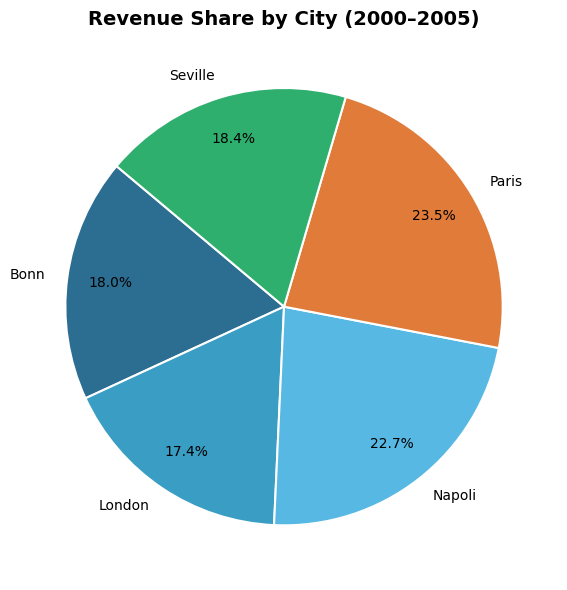

In [37]:
# Sum revenue per city
city_rev = df.groupby('City')['Revenue(£)'].sum()

fig, ax = plt.subplots(figsize=(7, 6))
wedge_colors = ['#2C6E91','#3A9DC4','#56B8E3','#E07B3A','#2FAF6E']

ax.pie(city_rev, labels=city_rev.index, autopct='%1.1f%%',
       colors=wedge_colors, startangle=140,
       pctdistance=0.8, wedgeprops={'edgecolor':'white','linewidth':1.5})


ax.set_title('Revenue Share by City (2000–2005)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart5_revenue_pie.png', dpi=150, bbox_inches='tight')
plt.show()